In [7]:
# ETL + Machine Learning para Previsão de Vendas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

Dados carregados com sucesso!
   ID da Venda       Data da Venda  ID Produto       Produto e Categoria  \
0            1 2023-07-01 08:30:49         101       Guarda-roupa,Móveis   
1            2 2023-06-02 11:59:00         102  Livro de História,Livros   
2            3 2023-07-30 09:18:29         103        Calça Jeans,Roupas   
3            4 2023-05-10 06:09:06         104  Quebra-cabeça,Brinquedos   
4            5 2023-08-11 00:01:14         105  Livro de Receitas,Livros   

   Quantidade  Preço Unitário   -  Preço Total Método de Pagamento    Canal  
0           5          249.27 NaN      1246.35                 PIX  Website  
1           9          590.11 NaN      5310.99   CARTÃO DE CRÉDITO  Website  
2           4          120.26 NaN       481.04                 PIX  Website  
3          10          599.06 NaN      5990.60   CARTÃO DE CRÉDITO  Website  
4           3          600.94 NaN      1802.82                 PIX  Website  
   ID da Venda       Data da Venda  ID Produt

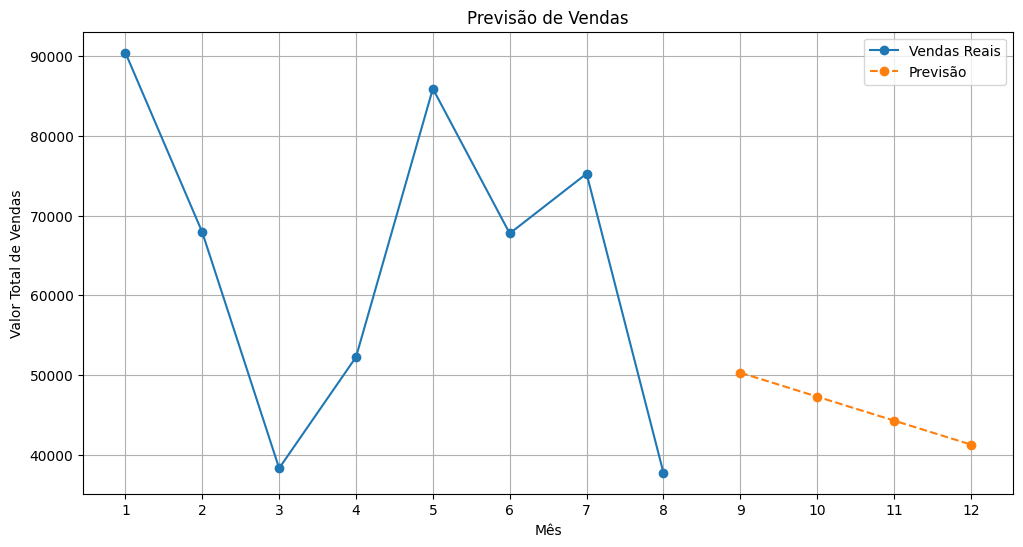

In [15]:
# 1. EXTRAÇÃO DOS DADOS

arquivo = "Vendas - Ecommerce.xlsx"

# Lendo planilha
df = pd.read_excel("/content/Vendas - Ecommerce.xlsx")

print("Dados carregados com sucesso!")
print(df.head())
df.dropna(axis=1, inplace=True)
print(df.head())

# 2. TRANSFORMAÇÃO (ETL)

# Renomeando colunas
df.columns = [
    "id_venda",
    "data_venda",
    "id_produto",
    "produto_categoria",
    "quantidade",
    "preco_unitario",
    "preco_total",
    "metodo_pagamento",
    "canal"
]


# Convertendo data
df["data_venda"] = pd.to_datetime(df["data_venda"])

# Criando colunas auxiliares
df["ano"] = df["data_venda"].dt.year
df["mes"] = df["data_venda"].dt.month

# Verificando valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

# 3. AGREGAÇÃO MENSAL

# Soma das vendas por mês
vendas_mensais = (
    df.groupby(["ano", "mes"])["preco_total"]
    .sum()
    .reset_index()
)

# Ordenando
vendas_mensais = vendas_mensais.sort_values(["ano", "mes"])

print("\nVendas mensais:")
print(vendas_mensais)

# 4. FEATURES PARA MACHINE LEARNING


# Criando índice temporal
vendas_mensais["indice_tempo"] = np.arange(len(vendas_mensais))
# Features
X = vendas_mensais[["indice_tempo"]]

# Target
y = vendas_mensais["preco_total"]


# 5. TREINAMENTO DO MODELO


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

modelo = LinearRegression()

modelo.fit(X_train, y_train)


# 6. AVALIAÇÃO

previsoes_teste = modelo.predict(X_test)

mae = mean_absolute_error(y_test, previsoes_teste)

print(f"\nMAE (Erro Médio Absoluto): {mae:.2f}")


# 7. PREVISÃO DOS MESES FALTANTES


ultimo_ano = vendas_mensais["ano"].max()
ultimo_mes = vendas_mensais["mes"].max()

print(f"\nÚltimo mês encontrado: {ultimo_mes}")

meses_faltantes = list(range(ultimo_mes + 1, 13))

# Índice temporal futuro
ultimo_indice = vendas_mensais["indice_tempo"].max()

futuro = pd.DataFrame({
    "indice_tempo": np.arange(
        ultimo_indice + 1,
        ultimo_indice + 1 + len(meses_faltantes)
    ),
})

# Previsões
futuro["previsao_vendas"] = modelo.predict(futuro[["indice_tempo"]])


futuro["mes"] = meses_faltantes
futuro["ano"] = ultimo_ano

print("\nPrevisão dos próximos meses:")
print(futuro[["ano", "previsao_vendas"]])


# 8. VISUALIZAÇÃO


plt.figure(figsize=(12, 6))

# Histórico
plt.plot(
    vendas_mensais["mes"],
    vendas_mensais["preco_total"],
    marker="o",
    label="Vendas Reais"
)

# Previsões
plt.plot(
    futuro["mes"],
    futuro["previsao_vendas"],
    marker="o",
    linestyle="--",
    label="Previsão"
)

plt.title("Previsão de Vendas")
plt.xlabel("Mês")
plt.ylabel("Valor Total de Vendas")
plt.xticks(range(1, 13))
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
futuro.to_excel("previsao_vendas.xlsx", index=False)